In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [2]:
train = pd.read_csv("/content/train_transaction.csv")

print(train.shape)
train.head()

(59175, 394)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Check number of null values in each column
print(train.isnull().sum())

TransactionID         0
isFraud               0
TransactionDT         0
TransactionAmt        0
ProductCD             0
                  ...  
V335              43814
V336              43814
V337              43814
V338              43814
V339              43814
Length: 394, dtype: int64


In [4]:
X = train.drop('isFraud', axis=1)
y = train['isFraud']

X = X.select_dtypes(include=np.number)

print(X.shape)

(59175, 379)


In [5]:
X = X.fillna(X.median())

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
isFraud
0    46034
1     1306
Name: count, dtype: int64

After SMOTE:
isFraud
0    46034
1    46034
Name: count, dtype: int64


In [8]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [9]:
y_prob = model.predict_proba(X_test)[:, 1]

print(y_prob[:10])

[0.02733179 0.01104705 0.11691242 0.0116943  0.15166807 0.01438394
 0.00640761 0.03519322 0.01654493 0.03296747]


In [10]:
y_pred = (y_prob >= 0.5).astype(int)

In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     11509
           1       0.80      0.36      0.49       326

    accuracy                           0.98     11835
   macro avg       0.89      0.68      0.74     11835
weighted avg       0.98      0.98      0.98     11835



In [12]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[11479    30]
 [  209   117]]


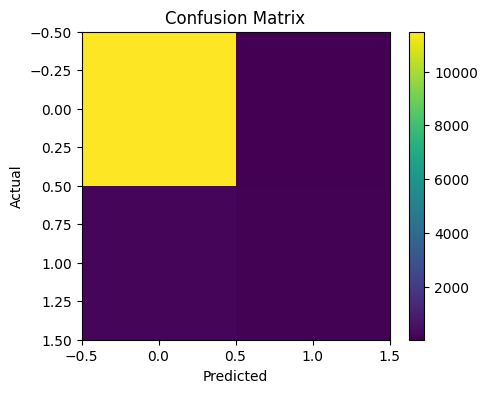

In [13]:
plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

In [14]:
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.8907179603905612


In [15]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print("Threshold:", threshold)
    print("Precision:", round(precision, 3))
    print("Recall:", round(recall, 3))
    print("F1 Score:", round(f1, 3))
    print("----------------------")

Threshold: 0.3
Precision: 0.539
Recall: 0.469
F1 Score: 0.502
----------------------
Threshold: 0.4
Precision: 0.673
Recall: 0.405
F1 Score: 0.506
----------------------
Threshold: 0.5
Precision: 0.796
Recall: 0.359
F1 Score: 0.495
----------------------
Threshold: 0.6
Precision: 0.856
Recall: 0.328
F1 Score: 0.475
----------------------
Threshold: 0.7
Precision: 0.876
Recall: 0.282
F1 Score: 0.427
----------------------


In [16]:
thresholds = np.arange(0.1, 0.91, 0.05)

best_threshold = 0
best_f1 = 0

for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    f1 = f1_score(y_test, y_pred_threshold)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("Best Threshold:", best_threshold)
print("Best F1 Score:", best_f1)

Best Threshold: 0.3500000000000001
Best F1 Score: 0.5202108963093146


In [17]:
final_pred = (y_prob >= best_threshold).astype(int)

print(classification_report(y_test, final_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99     11509
           1       0.61      0.45      0.52       326

    accuracy                           0.98     11835
   macro avg       0.80      0.72      0.75     11835
weighted avg       0.97      0.98      0.98     11835



In [18]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(15))

    Feature  Importance
269    V230    0.086602
356    V317    0.066704
5     card3    0.055034
236    V197    0.040083
68      V29    0.037226
97      V58    0.033744
195    V156    0.027651
293    V254    0.025099
96      V57    0.023440
108     V69    0.019966
12       C2    0.019687
21      C11    0.017368
297    V258    0.016521
321    V282    0.015591
322    V283    0.013992


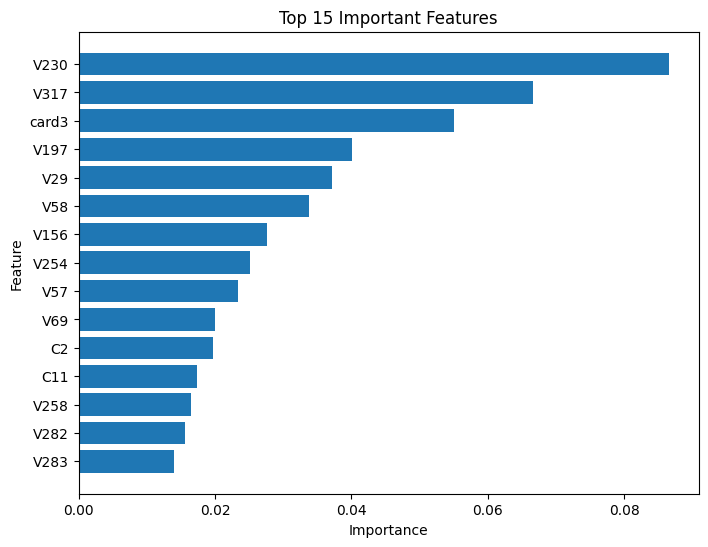

In [19]:
top_features = feature_importance.head(15)

plt.figure(figsize=(8,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [20]:
precision = precision_score(y_test, final_pred)
recall = recall_score(y_test, final_pred)
f1 = f1_score(y_test, final_pred)
auc = roc_auc_score(y_test, y_prob)

print("Final Results")
print("--------------------")
print("Precision :", round(precision, 4))
print("Recall    :", round(recall, 4))
print("F1 Score  :", round(f1, 4))
print("ROC-AUC   :", round(auc, 4))
print("Threshold :", best_threshold)

Final Results
--------------------
Precision : 0.6091
Recall    : 0.454
F1 Score  : 0.5202
ROC-AUC   : 0.8907
Threshold : 0.3500000000000001
